# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 5**. Fill in every member before submitting.

1. Full name: Adrien Labergere — Student ID: B00822082
2. Full name: Louis Bettelli — Student ID: B00820941
3. Full name: Oscar Moulet — Student ID: B00821262
4. Full name: Juliette Guilloux-Pinard — Student ID: B00825063
5. Full name: Apolline Seguin — Student ID: B00822617

**Group / repo name:** `aidams-lab2-moulet-bettelli-labergere-guilloux_pinard-seguin`  
**Submitter (one person):** Adrien Labergere 
**Repo URL:** https://github.com/adrienlabergere-creator/aidams-lab2-moulet-bettelli-labergere-guilloux_pinard-seguin

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [22]:
# Import libraries and load the plant-level GIST data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

DATA_FILE = "data/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"
plants = pd.read_excel(DATA_FILE, sheet_name="Plant data")
capacities = pd.read_excel(DATA_FILE, sheet_name="Plant capacities and status")

# Keep one row per plant by aggregating operating capacity across its units.
CAPACITY_COL = "Nominal crude steel capacity (ttpa)"
capacities[CAPACITY_COL] = pd.to_numeric(capacities[CAPACITY_COL], errors="coerce")
operating_capacity = (
    capacities[capacities["Status"].eq("operating")]
    .groupby("GEM plant ID")[CAPACITY_COL]
    .sum()
    .rename("Capacity (ttpa)")
)

df = plants.merge(operating_capacity, on="GEM plant ID", how="left")

# GIST reports capacity rather than one comparable observed-production value.
# We therefore use operating capacity as the target proxy for this lab.
df["production"] = df["Capacity (ttpa)"]

print("Shape:", df.shape)
print("Columns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nData types:\n", df.dtypes)
display(df.head())

Shape: (1293, 46)
Columns:
 ['GEM plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE status', 'Parent (English)', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit', 'Country/area', 'Region', 'Coordinates', 'Coordinate accuracy', 'GEM wiki page', 'Plant age', 'Announced date', 'Construction date', 'Start date', 'Pre-retirement announcement date', 'Idled date', 'Retired date', 'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)', 'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)', 'Category steel product', 'Steel products', 'Steel sector end users', 'Workforce size', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel certification', 'Main production equipment', 'Power source', 'Iron ore source', 'Met coal source', 'Capacity (tt

,GEM plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM entity ID,Owner PermID,SOE status,...,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel certification,Main production equipment,Power source,Iron ore source,Met coal source,Capacity (ttpa),production
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,"EEY Iron and Steel, Nursan Steel Payas Plant (...",NaN,ABA Çelik Demir LŞ,ABA Demir ve Çelik İthalat İhracat Ticaret,E100000131190,unknown,NaN,...,900,unknown,unknown,no,EAF,unknown,unknown,NaN,1100.0,1100.0
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Groot Suisse Oshana plant,NaN,Abba Steel Ltd,NaN,E100001012072,unknown,NaN,...,5500,unknown,unknown,no,EAF,unknown,unknown,NaN,NaN,NaN
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,"AESW, ASW, AEMZ, AEMK",Абинский ЭлектроМеталлургический завод,Abinski Elektrometallurgicheski Zavod LLC,"ООО ""АБИНСКИЙ ЭЛЕКТРОМЕТАЛЛУРГИЧЕСКИЙ ЗАВОД""",E100000130999,5039667129,NaN,...,4500,2025-10-06 00:00:00,unknown,no,EAF,unknown,NaN,unknown,1600.0,1600.0
3,P100000120020,Abul Khair Steel Sitakunda plant,আবুল খায়ের স্টিল মেল্টিং লিমিটেড,"AKS Long Steel, AKS Sitakund, AKS Melting, Abu...",NaN,Abul Khair Steel Ltd,NaN,E100000131068,5074007077,NaN,...,unknown,unknown,unknown,no,EAF,"100MW Power Plant, in progress 50MW solar plant",unknown,unknown,1400.0,1400.0
4,P100000120620,Acciaierie d'Italia Taranto steel plant,NaN,"ILVA Taranto steel plant (predecessor), ILVA S...",NaN,Acciaierie d'italia SpA,NaN,E100001010116,5067495106,Full,...,11000,2025-04-30 00:00:00,2025-12-04 00:00:00,no,DRI; EAF; BF; BOF,unknown,unknown,unknown,NaN,NaN


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?


> **Answer.** The file has lots of missing values (SOE status, secondary capacities, names in other languages) and some numeric columns stored as text. There's no clean observed production column, so we use operating capacity as the target. Plant age, production equipment, workforce, country and status should be the main drivers.

### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [23]:
# Validate the raw modelling columns before cleaning
import pandera as pa
from pandera import Column, Check

schema_columns = {}
for column in ["production", "Capacity (ttpa)"]:
    if column in df.columns:
        schema_columns[column] = Column(float, nullable=True, checks=Check.ge(0))

schema = pa.DataFrameSchema(schema_columns, coerce=False)
try:
    schema.validate(df, lazy=True)
    print("Raw schema validation passed.")
except pa.errors.SchemaErrors as error:
    print("Raw schema validation reported issues:")
    display(error.failure_cases.head(10))

Raw schema validation passed.


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

> **Answer.** Nothing failed: our schema only checks that capacity is numeric and ≥ 0, with missing values allowed, and the raw file respects that. So the missing values are real data gaps rather than a schema that's too strict. Without this check, text or negative capacities could reach training silently, and at deployment the model could receive rows it was never trained on.

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [24]:
# Clean numeric fields and inspect the target distribution
model_df = df.copy()
for column in ["production", "Capacity (ttpa)", "Plant age (years)", "Plant age", "Workforce", "Workforce size"]:
    if column in model_df.columns:
        model_df[column] = pd.to_numeric(model_df[column], errors="coerce")

model_df = model_df.dropna(subset=["production"]).copy()
model_df = model_df[model_df["production"] >= 0].copy()

print("Rows after cleaning:", len(model_df))
print("Missing values in modelling table:")
display(model_df.isna().sum().sort_values(ascending=False).head(10))
print("Target skewness:", round(model_df["production"].skew(), 2))

# Capacity is highly right-skewed, so the models will use log1p(production) as target.
model_df["target_log"] = np.log1p(model_df["production"])
df = model_df

Rows after cleaning: 935
Missing values in modelling table:


SOE status                            784
Other plant names (other language)    675
Location address (other language)     556
Coking plant capacity (ttpa)          517
Ferronickel capacity (ttpa)           513
Owner (other language)                502
Pelletizing plant capacity (ttpa)     426
Sinter plant capacity (ttpa)          414
Other plant names (English)           366
Plant name (other language)           325
dtype: int64

Target skewness: 3.12


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?


> **Answer.** We convert numeric columns (some contain text like `>0`) and drop rows with no target, since they can't be used for training. We keep very large plants because they're real, not errors. The target is very skewed (skewness 3.1), so we model its log.

### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [25]:
# Feature engineering and model inputs
age_column = "Plant age (years)" if "Plant age (years)" in df.columns else "Plant age"
workforce_column = "Workforce" if "Workforce" in df.columns else "Workforce size"

if age_column in df.columns:
    df["Plant age squared"] = df[age_column].fillna(df[age_column].median()) ** 2
if workforce_column in df.columns:
    df["Log workforce"] = np.log1p(df[workforce_column].clip(lower=0))

# Do not use capacity as a predictor because it defines the target proxy.
candidate_features = [
    "Country/area", "Region", "Owner", "SOE status",
    "Main production equipment", age_column, "Plant age squared",
    workforce_column, "Log workforce"
]
model_features = [column for column in candidate_features if column in df.columns]
X = df[model_features].copy()
y = df["target_log"].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

print("Engineered features:", model_features)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Engineered features: ['Country/area', 'Region', 'Owner', 'SOE status', 'Main production equipment', 'Plant age', 'Plant age squared', 'Workforce size', 'Log workforce']
Numeric features: ['Plant age', 'Plant age squared', 'Workforce size', 'Log workforce']
Categorical features: ['Country/area', 'Region', 'Owner', 'SOE status', 'Main production equipment']


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?


> **Answer.** `Plant age squared` lets age have a non-linear effect: very new and very old plants can behave differently from mid-life ones. `Log workforce` measures the size of the plant's operations without letting the biggest sites dominate. Together they capture where a plant is in its lifecycle and how large it is.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


,Correlation with log production
target_log,1.000000
Log workforce,0.317196
Workforce size,0.305648
Plant age,0.084252
Plant age squared,0.046392


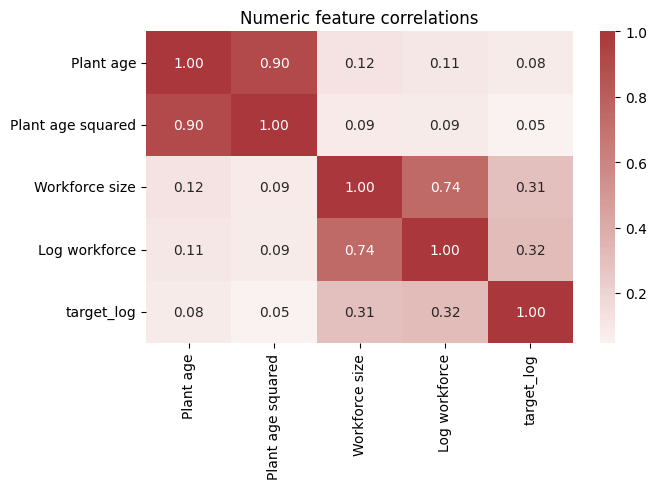

In [26]:
# Correlation matrix for numeric variables
correlation_columns = [column for column in numeric_features if column in df.columns] + ["target_log"]
correlations = df[correlation_columns].corr()
display(correlations["target_log"].sort_values(ascending=False).to_frame("Correlation with log production"))

plt.figure(figsize=(7, 5))
sns.heatmap(correlations, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?


> **Answer.** `Log workforce` is the most correlated with the target (≈ 0.32), while plant age barely is. `Workforce size` and `Log workforce` are redundant by construction, and so are `Plant age` and `Plant age squared`.

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [27]:
# Train/test split and baseline models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

def report_metrics(name, fitted_model):
    predictions = fitted_model.predict(X_test)
    return {
        "Model": name,
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "MAE": mean_absolute_error(y_test, predictions),
        "R2": r2_score(y_test, predictions),
    }

dummy_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])
linear_baseline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

dummy_pipeline.fit(X_train, y_train)
linear_baseline.fit(X_train, y_train)
baseline_results = pd.DataFrame([
    report_metrics("Dummy mean", dummy_pipeline),
    report_metrics("Preprocessed Ridge", linear_baseline),
])
display(baseline_results)

,Model,RMSE,MAE,R2
0,Dummy mean,2.143497,1.295096,-0.000259
1,Preprocessed Ridge,1.377421,0.744307,0.586952


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?


> **Answer.** The baseline shows the score you get without learning anything, so any model has to beat it. Our pipeline cuts RMSE from 2.14 to 1.38 and gets R² ≈ 0.59, so the features clearly carry useful information.

### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [28]:
# Multiple linear regression and coefficient table
linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression()),
])
linear_model.fit(X_train, y_train)

feature_names = linear_model.named_steps["preprocessing"].get_feature_names_out()
coefficients = pd.Series(
    linear_model.named_steps["model"].coef_, index=feature_names
).sort_values(key=abs, ascending=False)

print("Training metrics:", report_metrics("Linear regression", linear_model))
train_predictions = linear_model.predict(X_train)
print("Training RMSE:", round(mean_squared_error(y_train, train_predictions) ** 0.5, 3))
print("Test metrics:")
display(pd.DataFrame([report_metrics("Linear regression", linear_model)]))
display(coefficients.head(10).to_frame("Coefficient"))

Training metrics: {'Model': 'Linear regression', 'RMSE': 1.6357872324266294, 'MAE': 0.9391601373404137, 'R2': 0.41746679045615753}
Training RMSE: 0.225
Test metrics:


,Model,RMSE,MAE,R2
0,Linear regression,1.635787,0.93916,0.417467


,Coefficient
categorical__Owner_Anyang Iron & Steel Co Ltd,-8.438274
categorical__Owner_Hebei Jingdong Pipe Industry Co Ltd,-8.276055
categorical__Owner_Shijiazhuang Hongsen Melting & Casting Co Ltd,-8.086236
categorical__Owner_Quzhou Yuanli METAL Products Co Ltd,-8.048438
categorical__Main production equipment_BF; EAF; BOF,-7.878139
categorical__Owner_Uralskaya Stal JSC,7.870296
categorical__Main production equipment_BF,-7.826301
categorical__Owner_WISCO Group Kunming Steel Co Ltd,-7.614147
categorical__Owner_Henan Fengbao SPECIAL Steel Co Ltd,-7.586766
categorical__Owner_Jai Balaji Industries Ltd,-6.994011


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?


> **Answer.** Positive: `Owner = Uralskaya Stal JSC` (+7.9) means this owner's plant is predicted much larger than average. Negative: `Main production equipment = BF` (−7.8) means blast-furnace-only plants are predicted smaller, all else equal. These huge coefficients come from rare categories, and the gap between train RMSE (0.23) and test RMSE (1.64) shows the model overfits. We shouldn't read them as real performance drivers.

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [29]:
# Five-fold cross-validation for the baseline linear model
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(linear_baseline, X, y, cv=cv, scoring=scoring)

cv_summary = pd.DataFrame({
    "RMSE": -cv_scores["test_rmse"],
    "MAE": -cv_scores["test_mae"],
    "R2": cv_scores["test_r2"],
})
display(cv_summary)
print("Mean CV scores:")
display(cv_summary.agg(["mean", "std"]))

,RMSE,MAE,R2
0,1.377420,0.744299,0.586953
1,1.178569,0.687027,0.573174
2,1.629914,0.874638,0.455995
3,1.277384,0.728970,0.561552
4,1.368336,0.757309,0.451846


Mean CV scores:


,RMSE,MAE,R2
mean,1.366325,0.758448,0.525904
std,0.167905,0.070128,0.066340


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?


> **Answer.** Mean RMSE is 1.37 (std 0.17), MAE 0.76 and R² 0.53. Fold RMSE ranges from 1.18 to 1.63, so performance is fairly stable, though it still depends somewhat on which plants land in the test fold. That points to moderate variance, which makes sense with only ~900 plants.

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [30]:
# Compare three regression models on the same folds
models = {
    "Linear Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("preprocessing", preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}

comparison = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    comparison.append({
        "Model": name,
        "RMSE mean": -scores["test_rmse"].mean(),
        "RMSE std": scores["test_rmse"].std(),
        "MAE mean": -scores["test_mae"].mean(),
        "R2 mean": scores["test_r2"].mean(),
    })

comparison_df = pd.DataFrame(comparison).sort_values("RMSE mean")
display(comparison_df)

,Model,RMSE mean,RMSE std,MAE mean,R2 mean
1,Ridge,1.366325,0.150179,0.758448,0.525904
2,Random Forest,1.386856,0.185666,0.668852,0.513338
0,Linear Regression,1.572570,0.181740,0.903429,0.370931


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?


> **Answer.**
>
> | Model | RMSE | MAE | R² |
> |---|---|---|---|
> | Ridge | 1.37 | 0.76 | 0.53 |
> | Random Forest | 1.39 | 0.67 | 0.51 |
> | Linear Regression | 1.57 | 0.90 | 0.37 |
>
> Ridge has the lowest RMSE. The data has many one-hot columns (owners, countries) with few plants each, and regularisation stops the model from overfitting them like plain linear regression does. Random Forest is close and even has a better MAE, but Ridge is simpler to explain.

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [31]:
# Tune the best classical model from Task 3.2
ridge_pipeline = models["Ridge"]
param_grid = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0],
}

grid_search = GridSearchCV(
    ridge_pipeline, param_grid=param_grid, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best validation RMSE:", round(-grid_search.best_score_, 3))
print("Tuned test performance:")
display(pd.DataFrame([report_metrics("Tuned Ridge", best_pipeline)]))

Best parameters: {'model__alpha': 1.0}
Best validation RMSE: 1.37
Tuned test performance:


,Model,RMSE,MAE,R2
0,Tuned Ridge,1.377421,0.744307,0.586952


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?


> **Answer.** Tuning looks for the settings that generalise best, here the regularisation strength of Ridge. GridSearchCV picked alpha = 1.0, which is the default, so performance didn't change (CV RMSE 1.37). The limit comes from the data and features, not the hyperparameters.

## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [32]:
# Track two experiments with MLflow
import json
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("gist-steel-production")

experiments = [
    ("dummy_baseline", dummy_pipeline, {"model": "DummyRegressor"}),
    ("tuned_ridge", best_pipeline, grid_search.best_params_),
]
for run_name, fitted_model, parameters in experiments:
    metrics = report_metrics(run_name, fitted_model)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({key: str(value) for key, value in parameters.items()})
        mlflow.log_metrics({
            "rmse": metrics["RMSE"],
            "mae": metrics["MAE"],
            "r2": metrics["R2"],
        })
        with open("feature_list.json", "w") as file:
            json.dump(model_features, file)
        mlflow.log_artifact("feature_list.json")
print("Two experiments logged to the local MLflow database.")

Two experiments logged to the local MLflow database.


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?


> **Answer.** MLflow saves the parameters, metrics and artifacts (like the feature list) of each run in one place. You can compare runs side by side and reproduce any of them later. With manual tracking it's easy to lose which settings produced which score.

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [33]:
# Optuna search for Ridge regularisation, logged to the same MLflow store
import optuna

mlflow_tracking_uri = "sqlite:///mlflow.db"

def ridge_objective(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
    candidate = Pipeline([
        ("preprocessing", preprocessor),
        ("model", Ridge(alpha=alpha)),
    ])
    scores = cross_validate(candidate, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    return -scores["test_score"].mean()

optuna_callbacks = []
try:
    from optuna.integration import MLflowCallback
    optuna_callbacks.append(
        MLflowCallback(tracking_uri=mlflow_tracking_uri, metric_name="rmse")
    )
except (ImportError, TypeError):
    print("Optuna-MLflow integration is unavailable; running without the callback.")

study = optuna.create_study(direction="minimize", study_name="ridge-tuning")
study.optimize(
    ridge_objective, n_trials=30,
    callbacks=optuna_callbacks, show_progress_bar=False
)
print("Trials:", len(study.trials))
print("Best parameters:", study.best_params)
print("Best CV RMSE:", round(study.best_value, 3))
print("Untuned Ridge CV RMSE:", round(comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE mean"].iloc[0], 3))

C:\Users\adrie\AppData\Local\Temp\ipykernel_13460\2339067489.py:19: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  MLflowCallback(tracking_uri=mlflow_tracking_uri, metric_name="rmse")
[I 2026-09-25 10:31:29,876] A new study created in memory with name: ridge-tuning
[I 2026-09-25 10:31:30,097] Trial 0 finished with value: 1.519826358540311 and parameters: {'alpha': 0.006960505755858511}. Best is trial 0 with value: 1.519826358540311.
[I 2026-09-25 10:31:30,420] Trial 1 finished with value: 1.5254359724721163 and parameters: {'alpha': 0.005855785603531507}. Best is trial 0 with value: 1.519826358540311.
[I 2026-09-25 10:31:30,742] Trial 2 finished with value: 1.4910118106025165 and parameters: {'alpha': 0.0150982958995507}. Best is trial 2 with value: 1.4910118106025165.
[I 2026-09-25 10:31:30,981] Trial 3 finished with value: 1.6928254661748388 and parameters: {'alpha': 68.0

Trials: 30
Best parameters: {'alpha': 0.7793309871973775}
Best CV RMSE: 1.366
Untuned Ridge CV RMSE: 1.366


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?


> **Answer.** Optuna uses a Bayesian method (TPE by default): it looks at past trials to guess which alpha values are promising and tries those next. Grid search tests every value in a fixed list, and random search picks values blindly. After 30 trials Optuna found alpha ≈ 0.78, with the same CV RMSE (1.366) as the untuned Ridge.

### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [34]:
# Save and reload the complete preprocessing-plus-model pipeline
import joblib

MODEL_PATH = "best_steel_pipeline.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
loaded_pipeline = joblib.load(MODEL_PATH)

in_memory_metrics = report_metrics("In-memory model", best_pipeline)
loaded_metrics = report_metrics("Loaded model", loaded_pipeline)
storage_check = pd.DataFrame([in_memory_metrics, loaded_metrics])
display(storage_check)
print("RMSE difference after loading:", abs(in_memory_metrics["RMSE"] - loaded_metrics["RMSE"]))

,Model,RMSE,MAE,R2
0,In-memory model,1.377421,0.744307,0.586952
1,Loaded model,1.377421,0.744307,0.586952


RMSE difference after loading: 0.0


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?


> **Answer.** The model file alone isn't enough: you need the preprocessing, the feature list, the data version and the metrics to reuse or audit it later. Saving the whole pipeline, as we did, avoids mismatched encoders. In production we'd version each model in a registry like MLflow, along with its code and data version, and only promote it after validation.

## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


> **Answer.** We'd wrap the saved pipeline in a small REST API, or run it as a batch job each time a new GIST release comes out. Incoming rows go through the Pandera schema before `predict`, and invalid ones get rejected. We'd monitor RMSE/MAE once real production data arrives, plus the share of rejected rows. We didn't try TabFM, and we'd deploy the classical pipeline anyway, since TabFM's weights are non-commercial.

### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


> **Answer.** Rising errors or more rows rejected by the schema would signal that the model needs retraining. Data drift: newer plants shift the distribution of plant age. Concept drift: carbon rules or energy prices change how plant features relate to output. From our schema we'd watch `Capacity (ttpa)` first: a clear shift in its median or share of missing values compared with training would count as data drift.

## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?


> **Answer.**
>
> 1. **Most challenging step:** choosing and defining the target. GIST describes plants mainly through capacities, and real production figures are missing for most of them, so we had to use operating capacity instead. That choice affects everything after it. The model predicts how big a plant is rather than how much it actually produces, and we had to be careful not to use capacity columns as features, or the target would leak into the inputs. Handling the dataset's inconsistencies (text in numeric columns, many missing values, column names that change between releases) also took more time than training the models.
> 2. **With more plant-level data:** first we'd get real yearly production figures, so we could predict actual output and not just capacity. Utilisation rates, energy use, emissions and downtime would also help explain why two plants of the same size produce different amounts. Having several years per plant would let us validate over time (train on past years, test on the latest one), which is closer to how the model would really be used. With more rows we could also group rare owners and countries into broader categories, which would reduce the overfitting we saw in the linear regression.
> 3. **Communicating to a business audience:** we'd skip RMSE on a log scale and coefficients and translate the results into plain terms. For example: "the model is usually off by about a factor of two on plant size" and "plant equipment and workforce are the main drivers". A simple chart of the main drivers and a few real plant examples comparing predicted and actual values would make it concrete. We'd also be clear about the limits: capacity is not real production, and the model shows associations, not causes. It should support decisions, not replace expert judgement.